In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from pprint import pprint
import os
import math

from deepracer.tracks import TrackIO, Track
from deepracer.tracks.track_utils import track_breakdown, track_meta
from deepracer.logs import \
    SimulationLogsIO as slio, \
    NewRewardUtils as nr, \
    AnalysisUtils as au, \
    PlottingUtils as pu, \
    ActionBreakdownUtils as abu, \
    DeepRacerLog, \
    S3FileHandler, FSFileHandler

# Ignore deprecation warnings we have no power over
import warnings
warnings.filterwarnings('ignore')

In [5]:
tu = TrackIO()

for track in tu.get_tracks():
    print("{} - {}".format(track, track_meta.get(track[:-4], "I don't know")))

2022_april_open.npy - I don't know
2022_april_open_ccw.npy - I don't know
2022_april_open_cw.npy - I don't know
2022_april_pro.npy - I don't know
2022_april_pro_ccw.npy - I don't know
2022_april_pro_cw.npy - I don't know
2022_august_open.npy - I don't know
2022_august_open_ccw.npy - I don't know
2022_august_open_cw.npy - I don't know
2022_august_pro.npy - I don't know
2022_august_pro_ccw.npy - I don't know
2022_august_pro_cw.npy - I don't know
2022_july_open.npy - I don't know
2022_july_pro.npy - I don't know
2022_july_pro_ccw.npy - I don't know
2022_july_pro_cw.npy - I don't know
2022_june_open.npy - I don't know
2022_june_open_ccw.npy - I don't know
2022_june_open_cw.npy - I don't know
2022_june_pro.npy - I don't know
2022_june_pro_ccw.npy - I don't know
2022_june_pro_cw.npy - I don't know
2022_march_open.npy - I don't know
2022_march_open_ccw.npy - I don't know
2022_march_open_cw.npy - I don't know
2022_march_pro.npy - I don't know
2022_march_pro_ccw.npy - I don't know
2022_march_pr

Loaded 112 waypoints
0 : 0.0027081922369161654
1 : 0.0027086654822474215
2 : 0.0008913510799670871
3 : 0.0005979416751997584
4 : 0.00041763821715553456
5 : 0.0002596125469597893
6 : 0.00019192128421849364
7 : 7.899508834520452e-05
8 : 1.137907781074976e-05
9 : 0.00016920007032720716
10 : 0.0001580279447259622
11 : 3.3817420844187845e-05
12 : 3.3855064551373965e-05
13 : 4.514008607220052e-05
14 : 4.51024423650144e-05
15 : 1.1172125601244948e-05
16 : 2.2457129333040837e-05
17 : 0.0002031680484123749
18 : 0.00018048494944180107
19 : 0.00011292560964096254
20 : 0.0006770648424784774
21 : 0.0022568078038998837
22 : 0.0053713210235942915
23 : 2.7136699055824525
24 : 9.560155562120581
25 : 9.821393867656232
26 : 9.823657124021747
27 : 9.823086450853392
28 : 9.825273831519247
29 : 9.825045031889928
30 : 9.826771331876245
31 : 9.827920253745432
32 : 9.827361554444536
33 : 9.827113034108521
34 : 9.827225580157773
35 : 9.8268944465471
36 : 9.82498056124173
37 : 9.825034827027366
38 : 9.8227281592

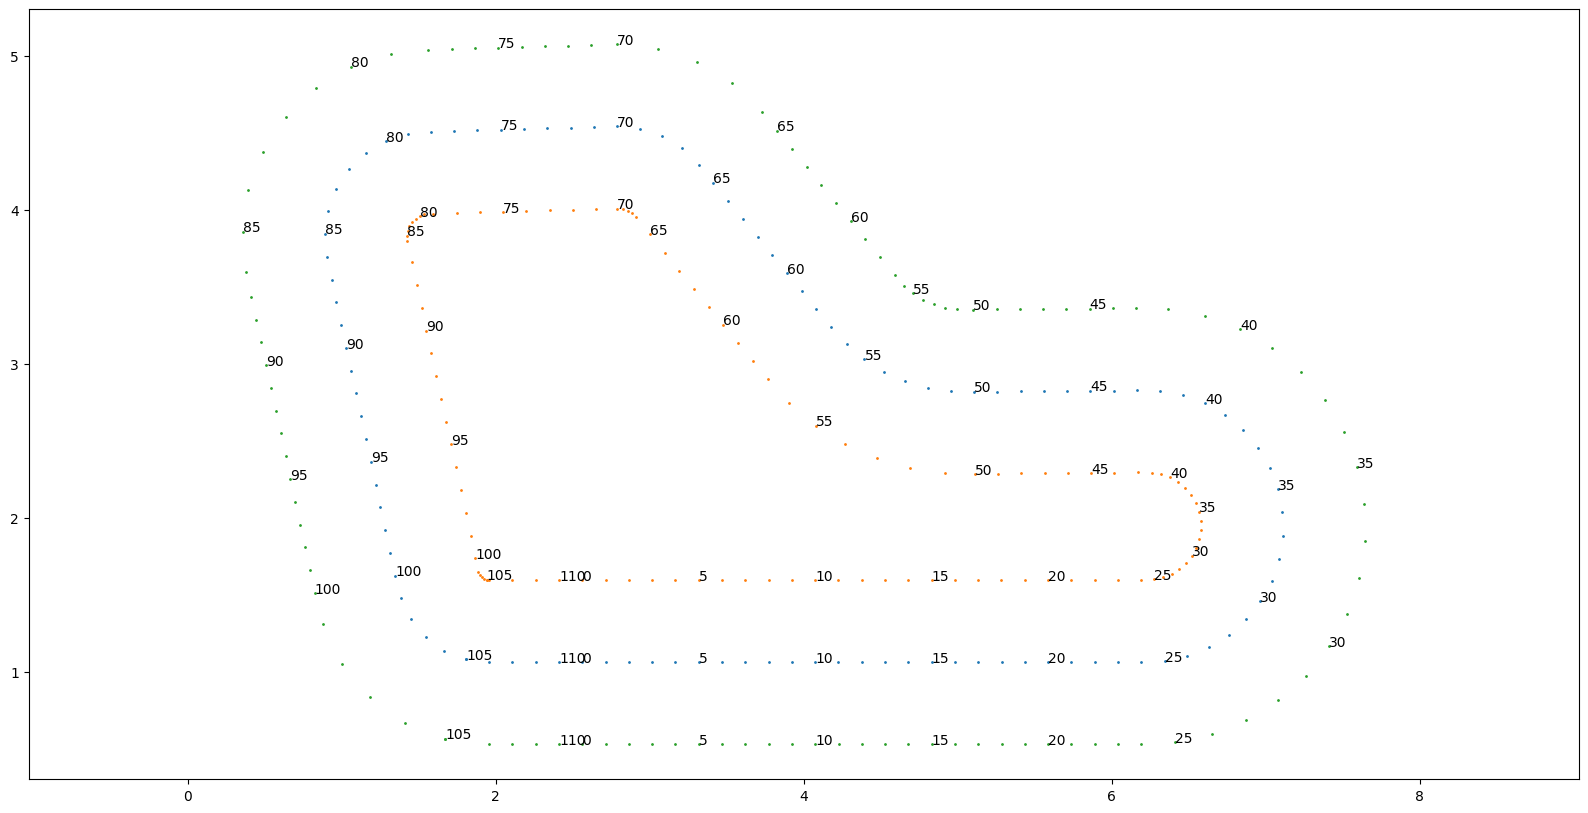

In [6]:
# loading track and printing data
track_name = "reInvent2019_wide.npy"
track: Track = tu.load_track(track_name)

pu.plot_trackpoints(track, annotate_every_nth=5)

##Looking at curvature##
def getDirection(wp1,wp2) -> float:
    delta_y = wp2[1] - wp1[1]
    delta_x = wp2[0] - wp1[0]
    wp_direction = math.atan2(delta_y,delta_x)
    wp_direction = math.degrees(wp_direction)
    return wp_direction

def getDiff(dir1, dir2) -> float:
    diff = abs(dir1 - dir2)
    if diff > 180:
        diff = 360 - diff #value between 0 and 180, likely between 0 and 30
    return diff

waypoints = track.center_line
for i in range(len(waypoints)-1):
    dir1 = getDirection(waypoints[i % (len(waypoints) - 1)], waypoints[(i+1) % (len(waypoints) - 1)])
    dir2 = getDirection(waypoints[(i+1) % (len(waypoints) - 1)], waypoints[(i+2) % (len(waypoints) - 1)])
    print(i, ":", getDiff(dir1, dir2))